<a href="https://colab.research.google.com/github/charithak2003/Data-Science/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Linear Regression

Linear regression is a fundamental statistical and machine learning technique. It's used to model the relationship between a dependent variable (what we want to predict) and one or more independent variables (the features we use to predict). For simple linear regression, we aim to find the best-fitting straight line through the data points.

### Steps we will follow:
1.  **Generate a Synthetic Dataset:** Create a simple dataset for demonstration.
2.  **Visualize the Data:** Plot the data to understand its distribution.
3.  **Implement Linear Regression:** Use scikit-learn to train a linear regression model.
4.  **Evaluate and Visualize:** Check the model's parameters and plot the regression line.

In [ ]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### 1. Generating a Synthetic Dataset

We'll create a dataset with a single feature (X) and a target variable (y) that has a linear relationship, plus some random noise.

In [ ]:
# Generate random data
np.random.seed(0) # for reproducibility
X = 2 * np.random.rand(100, 1) # 100 samples, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3X + noise

# Create a Pandas DataFrame for better handling
data = pd.DataFrame({'Feature_X': X.flatten(), 'Target_y': y.flatten()})
display(data.head())

,Feature_X,Target_y
0,1.097627,6.127731
1,1.430379,9.191963
2,1.205527,8.082243
3,1.089766,5.733055
4,0.847310,8.030181


### 2. Visualize the Data

Let's plot our synthetic data to see the linear relationship.

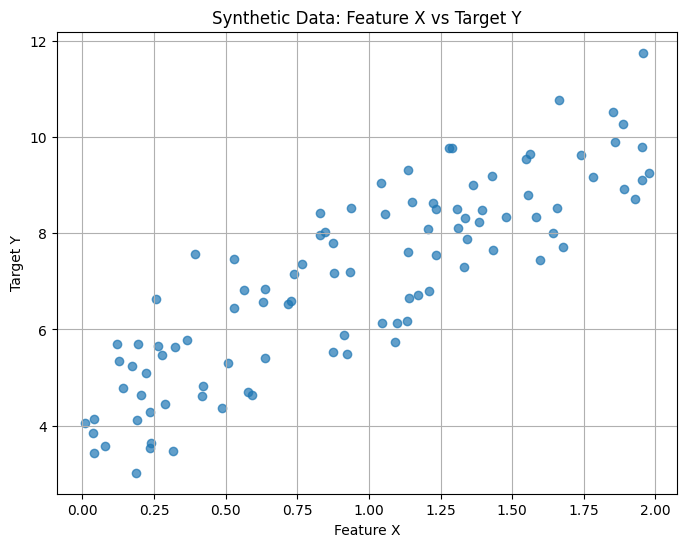

In [ ]:
# Plotting the data
plt.figure(figsize=(8, 6))
plt.scatter(data['Feature_X'], data['Target_y'], alpha=0.7)
plt.title('Synthetic Data: Feature X vs Target Y')
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.grid(True)
plt.show()

### 3. Implement Linear Regression

Now, we'll split our data into training and testing sets and train a `LinearRegression` model from scikit-learn.

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model object
model = LinearRegression()

# Train the model using the training sets
model.fit(X_train, y_train)

print(f"Model trained successfully!\n")
print(f"Coefficients (slope): {model.coef_[0][0]:.2f}")
print(f"Intercept: {model.intercept_[0]:.2f}")

Model trained successfully!

Coefficients (slope): 2.99
Intercept: 4.21


### 4. Evaluate and Visualize the Regression Line

Let's make predictions on the test set and visualize how well our regression line fits the data.

Mean squared error: 0.92
Coefficient of determination (R-squared): 0.65


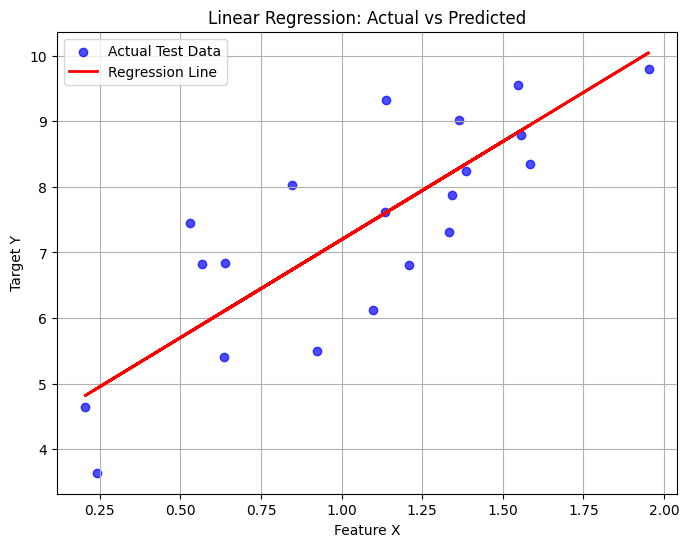

In [ ]:
# Make predictions using the test set
y_pred = model.predict(X_test)

# The mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.2f}")

# The coefficient of determination (R-squared)
r2 = r2_score(y_test, y_pred)
print(f"Coefficient of determination (R-squared): {r2:.2f}")

# Plotting the regression line
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.legend()
plt.grid(True)
plt.show()

### Closed-Form Solution (Normal Equation)

The closed-form solution directly calculates the optimal parameters by solving a matrix equation. It's given by the formula: `w = (XᵀX)⁻¹Xᵀy`, where `X` is the design matrix (features + bias term) and `y` is the target vector.

In [ ]:
import numpy as np

# Add a bias term (intercept) to X
# We need to reshape X to be a 2D array if it's not already, then add a column of ones.
X_b = np.c_[np.ones((len(X), 1)), X] # add x0 = 1 to each instance

# Calculate the parameters using the Normal Equation
# w = (XᵀX)⁻¹Xᵀy
# @ is matrix multiplication
# np.linalg.inv() computes the inverse of a matrix
# .T is for transpose

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print(f"Parameters from Normal Equation (Intercept, Coefficient):")
print(f"Intercept: {theta_best[0][0]:.2f}")
print(f"Coefficient: {theta_best[1][0]:.2f}")

# Make predictions with the closed-form solution
y_pred_normal_eq = X_b @ theta_best

# Evaluate the model (using the full dataset for simplicity here)
mse_normal_eq = mean_squared_error(y, y_pred_normal_eq)
r2_normal_eq = r2_score(y, y_pred_normal_eq)

print(f"\nMean Squared Error (Normal Equation): {mse_normal_eq:.2f}")
print(f"R-squared (Normal Equation): {r2_normal_eq:.2f}")

# Plotting the data with the Normal Equation line
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data')
plt.plot(X, y_pred_normal_eq, color='green', linewidth=2, label='Normal Equation Line')
plt.title('Linear Regression: Normal Equation')
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.legend()
plt.grid(True)
plt.show()

### Non-Closed-Form Solution (Gradient Descent)

Gradient Descent is an iterative optimization algorithm used to find the minimum of a function. For linear regression, it iteratively adjusts the model's parameters (weights and bias) in the direction opposite to the gradient of the cost function (Mean Squared Error) until the minimum is reached. We will use a simple Batch Gradient Descent implementation.

Key parameters for Gradient Descent:
-   `learning_rate`: Controls the step size at each iteration.
-   `n_iterations`: The number of times the parameters are updated.

In [ ]:
import numpy as np

# Re-add bias term (intercept) to X for Gradient Descent
# Ensure X_b is correctly shaped for matrix operations
X_b_gd = np.c_[np.ones((len(X), 1)), X]

# Initialize parameters (weights and bias) randomly
theta_gd = np.random.randn(2, 1) # [bias, coefficient]

# Hyperparameters for Gradient Descent
learning_rate = 0.01
n_iterations = 1000

# Gradient Descent loop
for iteration in range(n_iterations):
    # Calculate predictions
    y_pred_gd = X_b_gd @ theta_gd

    # Calculate the error
    error = y_pred_gd - y

    # Calculate gradients
    # Gradient for theta = (2/m) * X_b.T @ (X_b @ theta - y)
    gradients = 2/len(X) * X_b_gd.T @ error

    # Update parameters
    theta_gd = theta_gd - learning_rate * gradients

print(f"Parameters from Gradient Descent (Intercept, Coefficient):")
print(f"Intercept: {theta_gd[0][0]:.2f}")
print(f"Coefficient: {theta_gd[1][0]:.2f}")

# Make predictions with the Gradient Descent solution
y_pred_gd = X_b_gd @ theta_gd

# Evaluate the model
mse_gd = mean_squared_error(y, y_pred_gd)
r2_gd = r2_score(y, y_pred_gd)

print(f"\nMean Squared Error (Gradient Descent): {mse_gd:.2f}")
print(f"R-squared (Gradient Descent): {r2_gd:.2f}")

# Plotting the data with the Gradient Descent line
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data')
plt.plot(X, y_pred_gd, color='purple', linewidth=2, label='Gradient Descent Line')
plt.title('Linear Regression: Gradient Descent')
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.legend()
plt.grid(True)
plt.show()